# Forecasting International Trade Activity Using Machine Learning

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

## 1. Data Loading and Integration
Monthly trade files for the 18 selected G20 economies were loaded and combined before being merged with the external economic datasets.

In [2]:
trade_files = [
    "data/raw/by_country/Argentina_trade_2014_2025.csv",
    "data/raw/by_country/Australia_trade_2014_2025.csv",
    "data/raw/by_country/Brazil_trade_2014_2025.csv",
    "data/raw/by_country/Canada_trade_2014_2025.csv",
    "data/raw/by_country/China_trade_2014_2025.csv",
    "data/raw/by_country/France_trade_2014_2025.csv",
    "data/raw/by_country/Germany_trade_2014_2025.csv",
    "data/raw/by_country/India_trade_2014_2025.csv",
    "data/raw/by_country/Indonesia_trade_2014_2025.csv",
    "data/raw/by_country/Italy_trade_2014_2025.csv",
    "data/raw/by_country/Japan_trade_2014_2025.csv",
    "data/raw/by_country/Mexico_trade_2014_2025.csv",
    "data/raw/by_country/Republic_of_Korea_trade_2014_2025.csv",
    "data/raw/by_country_second_key/Saudi_Arabia_trade_201401_202512.csv",
    "data/raw/by_country_second_key/South_Africa_trade_201401_202512.csv",
    "data/raw/by_country_second_key/Turkiye_trade_201401_202512.csv",
    "data/raw/by_country_second_key/United_Kingdom_trade_201401_202512.csv",
    "data/raw/by_country_second_key/United_States_trade_201401_202512.csv",
]

print("Number of selected trade files:", len(trade_files))

for file in trade_files:
    print(file)

Number of selected trade files: 18
data/raw/by_country/Argentina_trade_2014_2025.csv
data/raw/by_country/Australia_trade_2014_2025.csv
data/raw/by_country/Brazil_trade_2014_2025.csv
data/raw/by_country/Canada_trade_2014_2025.csv
data/raw/by_country/China_trade_2014_2025.csv
data/raw/by_country/France_trade_2014_2025.csv
data/raw/by_country/Germany_trade_2014_2025.csv
data/raw/by_country/India_trade_2014_2025.csv
data/raw/by_country/Indonesia_trade_2014_2025.csv
data/raw/by_country/Italy_trade_2014_2025.csv
data/raw/by_country/Japan_trade_2014_2025.csv
data/raw/by_country/Mexico_trade_2014_2025.csv
data/raw/by_country/Republic_of_Korea_trade_2014_2025.csv
data/raw/by_country_second_key/Saudi_Arabia_trade_201401_202512.csv
data/raw/by_country_second_key/South_Africa_trade_201401_202512.csv
data/raw/by_country_second_key/Turkiye_trade_201401_202512.csv
data/raw/by_country_second_key/United_Kingdom_trade_201401_202512.csv
data/raw/by_country_second_key/United_States_trade_201401_202512.csv

In [3]:
all_data = []

for file in trade_files:
    temp = pd.read_csv(file)
    all_data.append(temp)

trade_df = pd.concat(all_data, ignore_index=True)

print("Combined trade data shape:", trade_df.shape)
print("Number of countries:", trade_df["country_name"].nunique())
print("Countries:")
print(sorted(trade_df["country_name"].unique()))

Combined trade data shape: (5066, 48)
Number of countries: 18
Countries:
['Argentina', 'Australia', 'Brazil', 'Canada', 'China', 'France', 'Germany', 'India', 'Indonesia', 'Italy', 'Japan', 'Mexico', 'Republic_of_Korea', 'Saudi_Arabia', 'South_Africa', 'Turkiye', 'United_Kingdom', 'United_States']


In [4]:
trade_df = trade_df[(trade_df["period"] >= 201401) & (trade_df["period"] <= 202412)]

print("Shape after keeping 2014 to 2024:", trade_df.shape)
print("Minimum period:", trade_df["period"].min())
print("Maximum period:", trade_df["period"].max())
print("Number of countries:", trade_df["country_name"].nunique())

Shape after keeping 2014 to 2024: (4668, 48)
Minimum period: 201401
Maximum period: 202412
Number of countries: 18


In [5]:
trade_df["date"] = pd.to_datetime(
    trade_df["period"].astype(str),
    format="%Y%m"
)

trade_df["year"] = trade_df["date"].dt.year
trade_df["month"] = trade_df["date"].dt.month
trade_df["quarter"] = trade_df["date"].dt.quarter

print(trade_df[["period", "date", "year", "month", "quarter"]].head())

   period       date  year  month  quarter
0  201401 2014-01-01  2014      1        1
1  201401 2014-01-01  2014      1        1
2  201402 2014-02-01  2014      2        1
3  201402 2014-02-01  2014      2        1
4  201403 2014-03-01  2014      3        1


In [6]:
trade_df = trade_df[
    [
        "country_name",
        "period",
        "date",
        "year",
        "month",
        "quarter",
        "flowCode",
        "flowDesc",
        "primaryValue"
    ]
]
print("Clean Trade data shape:",trade_df.shape)
print(trade_df.head())

Clean Trade data shape: (4668, 9)
  country_name  period       date  year  month  quarter flowCode flowDesc  \
0    Argentina  201401 2014-01-01  2014      1        1        M   Import   
1    Argentina  201401 2014-01-01  2014      1        1        X   Export   
2    Argentina  201402 2014-02-01  2014      2        1        M   Import   
3    Argentina  201402 2014-02-01  2014      2        1        X   Export   
4    Argentina  201403 2014-03-01  2014      3        1        M   Import   

   primaryValue  
0  5.218059e+09  
1  4.275126e+09  
2  5.539307e+09  
3  4.647254e+09  
4  5.524368e+09  


In [7]:
key_cols = ["country_name", "flowCode", "date"]

print(
    "Duplicate rows:",
    trade_df.duplicated(subset=key_cols).sum()
)

series_months = (
    trade_df.groupby(["country_name", "flowCode"])["date"]
    .nunique()
    .sort_values()
)

print("Country-flow series:", len(series_months))
print("Minimum months:", series_months.min())
print("Maximum months:", series_months.max())

display(series_months[series_months < 132])

Duplicate rows: 0
Country-flow series: 36
Minimum months: 108
Maximum months: 132


country_name  flowCode
China         X           108
              M           108
Saudi_Arabia  M           117
              X           117
Indonesia     M           130
              X           130
South_Africa  M           131
              X           131
Name: date, dtype: int64

In [8]:
expected_months = pd.date_range(
    "2014-01-01",
    "2024-12-01",
    freq="MS"
)

missing_summary = []

In [9]:
for (country, flow), group in trade_df.groupby(
    ["country_name", "flowCode"]
):
    available = pd.DatetimeIndex(group["date"])
    missing = expected_months.difference(available)

    if len(missing) > 0:
        missing_summary.append({
            "country": country,
            "flow": flow,
            "count": len(missing),
            "missing_months": ", ".join(
                missing.strftime("%Y-%m")
            )
        })

In [10]:
missing_summary_df = pd.DataFrame(missing_summary)

display(missing_summary_df)

,country,flow,count,missing_months
0,China,M,24,"2014-01, 2014-02, 2014-03, 2014-04, 2014-05, 2..."
1,China,X,24,"2014-01, 2014-02, 2014-03, 2014-04, 2014-05, 2..."
2,Indonesia,M,2,"2014-11, 2014-12"
3,Indonesia,X,2,"2014-11, 2014-12"
4,Saudi_Arabia,M,15,"2014-01, 2014-02, 2014-03, 2014-04, 2014-05, 2..."
5,Saudi_Arabia,X,15,"2014-01, 2014-02, 2014-03, 2014-04, 2014-05, 2..."
6,South_Africa,M,1,2020-12
7,South_Africa,X,1,2020-12


In [11]:
for _, row in missing_summary_df.iterrows():
    print(f"\n{row['country']} — {row['flow']}")
    print(row["missing_months"])


China — M
2014-01, 2014-02, 2014-03, 2014-04, 2014-05, 2014-06, 2014-07, 2014-08, 2014-09, 2014-10, 2014-11, 2014-12, 2015-01, 2015-02, 2015-03, 2015-04, 2015-05, 2015-06, 2015-07, 2015-08, 2015-09, 2015-10, 2015-11, 2015-12

China — X
2014-01, 2014-02, 2014-03, 2014-04, 2014-05, 2014-06, 2014-07, 2014-08, 2014-09, 2014-10, 2014-11, 2014-12, 2015-01, 2015-02, 2015-03, 2015-04, 2015-05, 2015-06, 2015-07, 2015-08, 2015-09, 2015-10, 2015-11, 2015-12

Indonesia — M
2014-11, 2014-12

Indonesia — X
2014-11, 2014-12

Saudi_Arabia — M
2014-01, 2014-02, 2014-03, 2014-04, 2014-05, 2014-06, 2014-07, 2014-08, 2014-09, 2014-10, 2014-11, 2014-12, 2017-10, 2017-11, 2017-12

Saudi_Arabia — X
2014-01, 2014-02, 2014-03, 2014-04, 2014-05, 2014-06, 2014-07, 2014-08, 2014-09, 2014-10, 2014-11, 2014-12, 2017-10, 2017-11, 2017-12

South_Africa — M
2020-12

South_Africa — X
2020-12


In [12]:
test_2024 = trade_df[
    trade_df["year"] == 2024
]

print("2024 rows:", len(test_2024))
print(
    "Duplicate 2024 rows:",
    test_2024.duplicated(
        ["country_name", "flowCode", "date"]
    ).sum()
)

2024 rows: 432
Duplicate 2024 rows: 0


In [13]:
test_counts = (
    test_2024.groupby(
        ["country_name", "flowCode"]
    )["date"]
    .nunique()
)

print("Minimum 2024 months:", test_counts.min())
print("Maximum 2024 months:", test_counts.max())

Minimum 2024 months: 12
Maximum 2024 months: 12


In [14]:
external_df = pd.read_csv("external_features_with_fedfunds.csv")

print("External features shape:", external_df.shape)
print(external_df.head())
print("columns:")
print(external_df.columns.tolist())

External features shape: (132, 15)
       period  crude_oil_avg_usd  brent_price_usd  dubai_price_usd  \
0  2014-01-01           102.0967           107.42           104.01   
1  2014-02-01           104.8267           108.81           104.94   
2  2014-03-01           104.0400           107.40           104.15   
3  2014-04-01           104.8667           107.79           104.73   
4  2014-05-01           105.7133           109.68           105.60   

   wti_price_usd  commodity_total_index  energy_index  non_energy_index  \
0          94.86               119.9302      131.2182           97.0601   
1         100.73               122.0227      133.9666           97.9067   
2         100.57               120.4567      130.6676           99.9456   
3         102.08               120.4596      130.6783           99.9672   
4         101.86               121.4330      132.3273           99.5266   

   agriculture_index  food_index  fertilizers_index  metals_minerals_index  \
0           100

In [15]:
external_df["date"] = pd.to_datetime(external_df["period"])
external_df = external_df.drop(columns=["period"])
print("External features after date cleanup:")
print(external_df.head())
print("Shape:", external_df.shape)

External features after date cleanup:
   crude_oil_avg_usd  brent_price_usd  dubai_price_usd  wti_price_usd  \
0           102.0967           107.42           104.01          94.86   
1           104.8267           108.81           104.94         100.73   
2           104.0400           107.40           104.15         100.57   
3           104.8667           107.79           104.73         102.08   
4           105.7133           109.68           105.60         101.86   

   commodity_total_index  energy_index  non_energy_index  agriculture_index  \
0               119.9302      131.2182           97.0601           100.9646   
1               122.0227      133.9666           97.9067           103.2064   
2               120.4567      130.6676           99.9456           108.0716   
3               120.4596      130.6783           99.9672           107.3121   
4               121.4330      132.3273           99.5266           106.8779   

   food_index  fertilizers_index  metals_mineral

In [16]:
model_df = pd.merge(
    trade_df,
    external_df,
    on="date",
    how="left"
)
print("Merged model data shape:", model_df.shape)
print(model_df.head())

Merged model data shape: (4668, 23)
  country_name  period       date  year  month  quarter flowCode flowDesc  \
0    Argentina  201401 2014-01-01  2014      1        1        M   Import   
1    Argentina  201401 2014-01-01  2014      1        1        X   Export   
2    Argentina  201402 2014-02-01  2014      2        1        M   Import   
3    Argentina  201402 2014-02-01  2014      2        1        X   Export   
4    Argentina  201403 2014-03-01  2014      3        1        M   Import   

   primaryValue  crude_oil_avg_usd  ...  commodity_total_index  energy_index  \
0  5.218059e+09           102.0967  ...               119.9302      131.2182   
1  4.275126e+09           102.0967  ...               119.9302      131.2182   
2  5.539307e+09           104.8267  ...               122.0227      133.9666   
3  4.647254e+09           104.8267  ...               122.0227      133.9666   
4  5.524368e+09           104.0400  ...               120.4567      130.6676   

   non_energy_index 

In [17]:
macro_df = pd.read_csv("new_external_macro_features_2014_2024.csv")
print("Macro external feat shape:", macro_df.shape)
print(macro_df.head())
print("Columns:")
print(macro_df.columns.tolist())

Macro external feat shape: (132, 8)
         date  usd_broad_index  us_industrial_production   us_cpi  \
0  2014-01-01        94.464748                  100.1599  235.288   
1  2014-02-01        94.645582                  100.9168  235.547   
2  2014-03-01        94.440821                  101.8942  236.028   
3  2014-04-01        93.995550                  101.9928  236.468   
4  2014-05-01        93.670029                  102.3836  236.918   

   fed_funds_rate  us_10y_treasury_rate  global_policy_uncertainty  \
0            0.07              2.858095                 115.257559   
1            0.07              2.709474                 101.147273   
2            0.08              2.723333                 114.652379   
3            0.09              2.705238                 110.450150   
4            0.09              2.559048                 106.839074   

   deep_sea_freight_ppi  
0                 263.0  
1                 262.2  
2                 262.1  
3                 263.3 

In [18]:
macro_df["date"] = pd.to_datetime(macro_df["date"])
macro_df = macro_df.drop(columns=["fed_funds_rate"])
model_df = pd.merge(
    model_df,
    macro_df,
    on="date",
    how="left"
)

print("Model data shape w macro feat:", model_df.shape)
print(model_df.head())

Model data shape w macro feat: (4668, 29)
  country_name  period       date  year  month  quarter flowCode flowDesc  \
0    Argentina  201401 2014-01-01  2014      1        1        M   Import   
1    Argentina  201401 2014-01-01  2014      1        1        X   Export   
2    Argentina  201402 2014-02-01  2014      2        1        M   Import   
3    Argentina  201402 2014-02-01  2014      2        1        X   Export   
4    Argentina  201403 2014-03-01  2014      3        1        M   Import   

   primaryValue  crude_oil_avg_usd  ...  metals_minerals_index  \
0  5.218059e+09           102.0967  ...                88.0757   
1  4.275126e+09           102.0967  ...                88.0757   
2  5.539307e+09           104.8267  ...                86.1633   
3  4.647254e+09           104.8267  ...                86.1633   
4  5.524368e+09           104.0400  ...                82.9794   

   base_metals_index  precious_metals_index  fed_funds_rate  usd_broad_index  \
0            88.13

## 2. Data Cleaning and External Feature Preparation
Missing values, duplicated variables and incomplete indicators were reviewed before the final modelling dataset was prepared.

In [19]:
missing = model_df.isna().sum()
missing=missing[missing>0]

print("Missing values:")
print(missing)

Missing values:
Series([], dtype: int64)


In [20]:
cols_to_drop = [
    "brent_price_usd",
    "dubai_price_usd",
    "wti_price_usd",
    "commodity_total_index",
    "agriculture_index",
    "metals_minerals_index"
]

model_df = model_df.drop(columns=cols_to_drop, errors="ignore")

In [21]:
model_df.to_csv("clean_final_data.csv", index=False)
print("Saved file: clean_final_data.csv")
print("Final shape:", model_df.shape)

Saved file: clean_final_data.csv
Final shape: (4668, 23)


## 3. Lagged External Variables

The external economic indicators were lagged by one month so that each forecast used information available before the target month.

In [22]:
external_cols = [
    "crude_oil_avg_usd",
    "energy_index",
    "non_energy_index",
    "food_index",
    "fertilizers_index",
    "base_metals_index",
    "precious_metals_index",
    "fed_funds_rate",
    "usd_broad_index",
    "us_industrial_production",
    "us_cpi",
    "us_10y_treasury_rate",
    "global_policy_uncertainty",
    "deep_sea_freight_ppi"
]

monthly_external = model_df[["date"] + external_cols].drop_duplicates()

monthly_external = monthly_external.sort_values("date")

for col in external_cols:
    monthly_external[col + "_lag1"] = monthly_external[col].shift(1)

print(monthly_external.head())

        date  crude_oil_avg_usd  energy_index  non_energy_index  food_index  \
0 2014-01-01           102.0967      131.2182           97.0601    106.5227   
2 2014-02-01           104.8267      133.9666           97.9067    108.2873   
4 2014-03-01           104.0400      130.6676           99.9456    113.8253   
6 2014-04-01           104.8667      130.6783           99.9672    112.3142   
8 2014-05-01           105.7133      132.3273           99.5266    112.0518   

   fertilizers_index  base_metals_index  precious_metals_index  \
0           105.6653            88.1316               100.5996   
2           105.6094            86.8503               105.0007   
4           102.5986            84.4461               107.2837   
6            94.9084            87.0879               103.9296   
8            96.0311            88.5446               102.9955   

   fed_funds_rate  usd_broad_index  ...  fertilizers_index_lag1  \
0            0.07        94.464748  ...                     N

In [23]:
lag_cols = ["date"] + [col + "_lag1" for col in external_cols]
model_df = pd.merge(
    model_df,
    monthly_external[lag_cols],
    on="date",
    how="left"
)
print("Shape after adding correct lag features:", model_df.shape)

Shape after adding correct lag features: (4668, 37)


In [24]:
lagged_external_cols = [
    col + "_lag1" for col in external_cols
]

model_df = model_df.dropna(
    subset=lagged_external_cols
)

In [25]:
print("Shape after lag cleanup:", model_df.shape)
print("First date:", model_df["date"].min())

Shape after lag cleanup: (4636, 37)
First date: 2014-02-01 00:00:00


In [26]:
model_df = model_df.drop(columns=external_cols)

print("Shape after removing current-month external values:", model_df.shape)
print(model_df.columns.tolist())

current_external_remaining = [
    col for col in external_cols
    if col in model_df.columns
]

print(
    "Current-month indicators remaining:",
    current_external_remaining
)

print(
    "Lagged indicators retained:",
    len(lagged_external_cols)
)

Shape after removing current-month external values: (4636, 23)
['country_name', 'period', 'date', 'year', 'month', 'quarter', 'flowCode', 'flowDesc', 'primaryValue', 'crude_oil_avg_usd_lag1', 'energy_index_lag1', 'non_energy_index_lag1', 'food_index_lag1', 'fertilizers_index_lag1', 'base_metals_index_lag1', 'precious_metals_index_lag1', 'fed_funds_rate_lag1', 'usd_broad_index_lag1', 'us_industrial_production_lag1', 'us_cpi_lag1', 'us_10y_treasury_rate_lag1', 'global_policy_uncertainty_lag1', 'deep_sea_freight_ppi_lag1']
Current-month indicators remaining: []
Lagged indicators retained: 14


In [27]:
target = model_df["primaryValue"]

print("Missing values:", target.isna().sum())
print("Zero values:", (target == 0).sum())
print("Negative values:", (target < 0).sum())
print("Minimum value:", target.min())

Missing values: 0
Zero values: 0
Negative values: 0
Minimum value: 2837983453.659


In [28]:
model_df["log_primaryValue"] = np.log1p(target)

print(
    model_df[
        ["primaryValue", "log_primaryValue"]
    ].head()
)

   primaryValue  log_primaryValue
2  5.539307e+09         22.435135
3  4.647254e+09         22.259542
4  5.524368e+09         22.432435
5  4.913932e+09         22.315340
6  5.414486e+09         22.412344


## 4. Exact 12-Month Seasonal Trade Lag

An exact date-based 12-month lag was created for each country and trade flow to capture recurring annual trade patterns.

In [29]:
lag_lookup = model_df[
    ["country_name", "flowCode", "date", "primaryValue"]
].copy()

lag_lookup["date"] = lag_lookup["date"] + pd.DateOffset(years=1)

lag_lookup = lag_lookup.rename(
    columns={"primaryValue": "trade_value_lag12"}
)

lag_lookup.head()

,country_name,flowCode,date,trade_value_lag12
2,Argentina,M,2015-02-01,5.539307e+09
3,Argentina,X,2015-02-01,4.647254e+09
4,Argentina,M,2015-03-01,5.524368e+09
5,Argentina,X,2015-03-01,4.913932e+09
6,Argentina,M,2015-04-01,5.414486e+09


In [30]:
rows_before_lag = len(model_df)

model_df = model_df.merge(
    lag_lookup,
    on=["country_name", "flowCode", "date"],
    how="left",
    validate="one_to_one"
)

In [31]:
print("Rows before merge:", rows_before_lag)
print("Rows after merge:", len(model_df))

print(
    "Rows with 12-month lag:",
    model_df["trade_value_lag12"].notna().sum()
)

print(
    "Rows without 12-month lag:",
    model_df["trade_value_lag12"].isna().sum()
)

Rows before merge: 4636
Rows after merge: 4636
Rows with 12-month lag: 4196
Rows without 12-month lag: 440


In [32]:
print("Rows with a true 12-month lag:", model_df["trade_value_lag12"].notna().sum())
print("Rows without a true 12-month lag:", model_df["trade_value_lag12"].isna().sum())

Rows with a true 12-month lag: 4196
Rows without a true 12-month lag: 440


## 5. Chronological Split and Seasonal Random Forest

The final seasonal dataset was divided chronologically, with observations before 2024 used for training and the 2024 observations reserved for testing.

In [33]:
seasonal_model_df = model_df.dropna(
    subset=["trade_value_lag12"]
).copy()

print("Rows kept:", len(seasonal_model_df))
print(
    "Missing lag values:",
    seasonal_model_df["trade_value_lag12"].isna().sum()
)

Rows kept: 4196
Missing lag values: 0


In [34]:
print(
    "2024 rows retained:",
    (seasonal_model_df["year"] == 2024).sum()
)

print(
    "First usable date:",
    seasonal_model_df["date"].min()
)

2024 rows retained: 432
First usable date: 2015-02-01 00:00:00


In [35]:
seasonal_model_df_encoded = pd.get_dummies(
    seasonal_model_df,
    columns=["country_name", "flowCode"],
    drop_first=True,
    dtype=int
)

In [36]:
print(
    "Encoded shape:",
    seasonal_model_df_encoded.shape
)

print(
    "Duplicate indices:",
    seasonal_model_df_encoded.index.duplicated().sum()
)

Encoded shape: (4196, 41)
Duplicate indices: 0


In [37]:
seasonal_train_df = seasonal_model_df_encoded[
    seasonal_model_df_encoded["year"] <= 2023
].copy()

seasonal_test_df = seasonal_model_df_encoded[
    seasonal_model_df_encoded["year"] == 2024
].copy()

In [38]:
print("Train shape:", seasonal_train_df.shape)
print("Test shape:", seasonal_test_df.shape)

print("Last training date:", seasonal_train_df["date"].max())
print("First test date:", seasonal_test_df["date"].min())

Train shape: (3764, 41)
Test shape: (432, 41)
Last training date: 2023-12-01 00:00:00
First test date: 2024-01-01 00:00:00


In [39]:
seasonal_drop_cols = [
    "primaryValue",
    "log_primaryValue",
    "date",
    "period",
    "year",
    "flowDesc"
]

In [40]:
X_train_seasonal = seasonal_train_df.drop(
    columns=seasonal_drop_cols
)

X_test_seasonal = seasonal_test_df.drop(
    columns=seasonal_drop_cols
)

In [41]:
y_train_seasonal = seasonal_train_df["log_primaryValue"]
y_test_seasonal = seasonal_test_df["log_primaryValue"]

In [42]:
print("X_train:", X_train_seasonal.shape)
print("X_test:", X_test_seasonal.shape)

print(
    "Same columns:",
    X_train_seasonal.columns.equals(
        X_test_seasonal.columns
    )
)

print(
    "Missing feature values:",
    X_train_seasonal.isna().sum().sum()
    + X_test_seasonal.isna().sum().sum()
)

X_train: (3764, 35)
X_test: (432, 35)
Same columns: True
Missing feature values: 0


In [43]:
non_numeric = X_train_seasonal.select_dtypes(
    exclude="number"
).columns.tolist()

print("Non-numeric features:", non_numeric)
print(
    "12-month lag included:",
    "trade_value_lag12" in X_train_seasonal.columns
)

Non-numeric features: []
12-month lag included: True


In [44]:
"trade_value_lag12" in X_train_seasonal.columns

True

In [45]:
rf_seasonal = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_seasonal.fit(
    X_train_seasonal,
    y_train_seasonal
)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [46]:
seasonal_pred_log = rf_seasonal.predict(
    X_test_seasonal
)

seasonal_pred = np.expm1(seasonal_pred_log)
seasonal_actual = np.expm1(y_test_seasonal)

In [47]:
seasonal_mae = mean_absolute_error(
    seasonal_actual,
    seasonal_pred
)

seasonal_rmse = np.sqrt(
    mean_squared_error(
        seasonal_actual,
        seasonal_pred
    )
)

seasonal_r2 = r2_score(
    seasonal_actual,
    seasonal_pred
)

seasonal_mape = mean_absolute_percentage_error(
    seasonal_actual,
    seasonal_pred
) * 100

In [48]:
print("MAE:", seasonal_mae)
print("RMSE:", seasonal_rmse)
print("R²:", seasonal_r2)
print("MAPE:", seasonal_mape)

MAE: 3935429623.9122915
RMSE: 6850486670.5301075
R²: 0.9904805046252555
MAPE: 6.763067971816304


In [49]:
rf_final = rf_seasonal
rf_actual = seasonal_actual
rf_predicted = seasonal_pred

print("Final Random Forest assigned")
print("Test observations:", len(rf_predicted))

Final Random Forest assigned
Test observations: 432


In [50]:
seasonal_test_meta = seasonal_model_df.loc[
    seasonal_test_df.index,
    ["country_name", "flowCode", "date"]
].copy()

In [51]:
seasonal_country_results = (
    seasonal_test_meta.reset_index(drop=True)
)

seasonal_country_results["Actual"] = np.asarray(
    seasonal_actual
)

seasonal_country_results["Predicted"] = np.asarray(
    seasonal_pred
)

In [52]:
print("Result rows:", len(seasonal_country_results))

print(
    "Countries:",
    seasonal_country_results["country_name"].nunique()
)

print(
    "Rows per country:",
    seasonal_country_results.groupby(
        "country_name"
    ).size().unique()
)

Result rows: 432
Countries: 18
Rows per country: [24]


In [53]:
country_metrics = []

for country, group in seasonal_country_results.groupby("country_name"):
    actual = group["Actual"]
    predicted = group["Predicted"]

    country_metrics.append({
        "Country": country,
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(
            mean_squared_error(actual, predicted)
        ),
        "R2": r2_score(actual, predicted),
        "MAPE": mean_absolute_percentage_error(
            actual,
            predicted
        ) * 100
    })

country_metrics_df = (
    pd.DataFrame(country_metrics)
    .sort_values("MAPE")
    .reset_index(drop=True)
)

print("Countries evaluated:", len(country_metrics_df))

display(
    country_metrics_df[
        ["Country", "R2", "MAPE"]
    ].round(3)
)

Countries evaluated: 18


,Country,R2,MAPE
0,France,0.779,4.195
1,Canada,-1.008,4.402
2,Japan,0.361,4.495
3,China,0.874,4.828
4,United_States,0.903,4.945
5,Italy,0.565,4.959
6,Australia,0.422,5.224
7,Turkiye,0.800,5.513
8,Saudi_Arabia,0.736,6.011
9,Indonesia,0.418,6.018


In [54]:
country_performance_table = country_metrics_df.copy()

country_performance_table["MAE (USD bn)"] = (
    country_performance_table["MAE"] / 1e9
)

country_performance_table["RMSE (USD bn)"] = (
    country_performance_table["RMSE"] / 1e9
)

country_performance_table = country_performance_table[
    [
        "Country",
        "MAE (USD bn)",
        "RMSE (USD bn)",
        "R2",
        "MAPE"
    ]
].rename(
    columns={
        "MAPE": "MAPE (%)"
    }
)

display(country_performance_table.round(3))

,Country,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,France,2.430,2.865,0.779,4.195
1,Canada,2.073,2.608,-1.008,4.402
2,Japan,2.722,3.126,0.361,4.495
3,China,12.821,16.369,0.874,4.828
4,United_States,12.572,17.151,0.903,4.945
5,Italy,2.682,3.371,0.565,4.959
6,Australia,1.365,1.581,0.422,5.224
7,Turkiye,1.405,1.732,0.800,5.513
8,Saudi_Arabia,1.373,1.712,0.736,6.011
9,Indonesia,1.293,1.578,0.418,6.018


In [55]:
country_plot_data = (
    country_performance_table
    .sort_values("MAPE (%)", ascending=True)
    .reset_index(drop=True)
)

country_plot_data[
    ["Country", "MAPE (%)"]
]

,Country,MAPE (%)
0,France,4.194722
1,Canada,4.401879
2,Japan,4.495370
3,China,4.827717
4,United_States,4.944567
5,Italy,4.959138
6,Australia,5.223967
7,Turkiye,5.512587
8,Saudi_Arabia,6.011268
9,Indonesia,6.018410


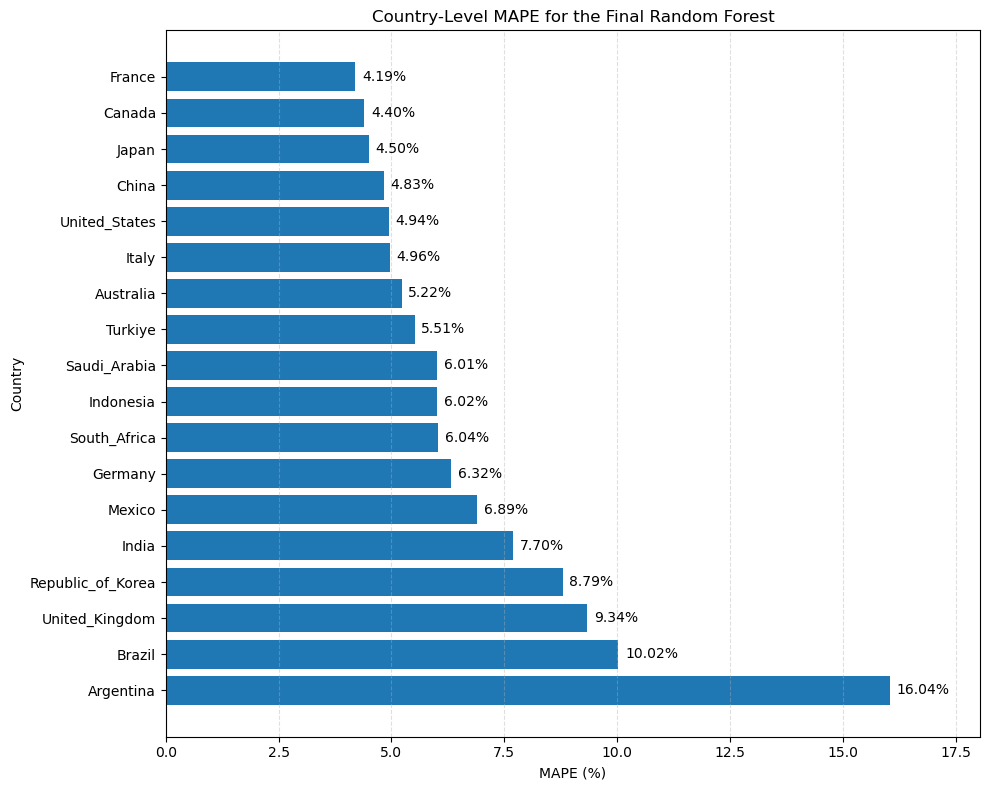

In [56]:
plt.figure(figsize=(10, 8))

bars = plt.barh(
    country_plot_data["Country"],
    country_plot_data["MAPE (%)"]
)

plt.xlabel("MAPE (%)")
plt.ylabel("Country")

plt.title(
    "Country-Level MAPE for the Final Random Forest"
)

plt.gca().invert_yaxis()

for bar in bars:
    value = bar.get_width()

    plt.text(
        value + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center"
    )

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.xlim(0, country_plot_data["MAPE (%)"].max() + 2)

plt.tight_layout()

plt.savefig(
    "Figure_2_7_2_1_Country_MAPE.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6. History-Only versus External Indicators

Two Random Forest configurations were compared to assess whether external economic indicators improved forecasting beyond historical seasonal trade information.

In [57]:
external_feature_columns = [
    col for col in X_train_seasonal.columns
    if col.endswith("_lag1")
]

print("External features removed:", len(external_feature_columns))

External features removed: 14


In [58]:
X_train_history = X_train_seasonal.drop(
    columns=external_feature_columns
)

X_test_history = X_test_seasonal.drop(
    columns=external_feature_columns
)

print("History-only train shape:", X_train_history.shape)
print("History-only test shape:", X_test_history.shape)

History-only train shape: (3764, 21)
History-only test shape: (432, 21)


In [59]:
rf_history = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_history.fit(
    X_train_history,
    y_train_seasonal
)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [60]:
history_pred_log = rf_history.predict(
    X_test_history
)

history_pred = np.expm1(history_pred_log)

In [61]:
history_mae = mean_absolute_error(
    seasonal_actual,
    history_pred
)

history_rmse = np.sqrt(
    mean_squared_error(
        seasonal_actual,
        history_pred
    )
)

history_r2 = r2_score(
    seasonal_actual,
    history_pred
)

history_mape = mean_absolute_percentage_error(
    seasonal_actual,
    history_pred
) * 100

In [62]:
history_external_comparison = pd.DataFrame({
    "Model": [
        "Seasonal history only",
        "Seasonal history plus external indicators"
    ],
    "MAE (USD bn)": [
        history_mae / 1e9,
        seasonal_mae / 1e9
    ],
    "RMSE (USD bn)": [
        history_rmse / 1e9,
        seasonal_rmse / 1e9
    ],
    "R2": [
        history_r2,
        seasonal_r2
    ],
    "MAPE (%)": [
        history_mape,
        seasonal_mape
    ]
})

display(history_external_comparison.round(3))

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,Seasonal history only,4.032,6.473,0.992,8.225
1,Seasonal history plus external indicators,3.935,6.850,0.990,6.763


In [63]:
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model.fit(
    X_train_seasonal,
    y_train_seasonal
)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [64]:
linear_pred_log = linear_model.predict(
    X_test_seasonal
)

linear_pred = np.expm1(linear_pred_log)

In [65]:
linear_mae = mean_absolute_error(
    seasonal_actual,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        seasonal_actual,
        linear_pred
    )
)

linear_r2 = r2_score(
    seasonal_actual,
    linear_pred
)

linear_mape = mean_absolute_percentage_error(
    seasonal_actual,
    linear_pred
) * 100

In [66]:
print("MAE:", linear_mae / 1e9)
print("RMSE:", linear_rmse / 1e9)
print("R²:", linear_r2)
print("MAPE:", linear_mape)

MAE: 13.417010604911328
RMSE: 25.980252879645903
R²: 0.8630828583886293
MAPE: 16.0390635952603


In [67]:
svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(
        kernel="rbf",
        C=10,
        epsilon=0.1
    ))
])

svr_model.fit(
    X_train_seasonal,
    y_train_seasonal
)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0


In [68]:
svr_pred_log = svr_model.predict(
    X_test_seasonal
)

svr_pred = np.expm1(svr_pred_log)

In [69]:
svr_mae = mean_absolute_error(
    seasonal_actual,
    svr_pred
)

svr_rmse = np.sqrt(
    mean_squared_error(
        seasonal_actual,
        svr_pred
    )
)

svr_r2 = r2_score(
    seasonal_actual,
    svr_pred
)

svr_mape = mean_absolute_percentage_error(
    seasonal_actual,
    svr_pred
) * 100

In [70]:
print("MAE:", svr_mae / 1e9)
print("RMSE:", svr_rmse / 1e9)
print("R²:", svr_r2)
print("MAPE:", svr_mape)

MAE: 10.88642617687501
RMSE: 20.915293241232945
R²: 0.911264174911564
MAPE: 20.704472503944626


In [71]:
from xgboost import XGBRegressor

In [72]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_seasonal,
    y_train_seasonal
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [73]:
xgb_pred_log = xgb_model.predict(
    X_test_seasonal
)

xgb_pred = np.expm1(xgb_pred_log)

In [74]:
xgb_mae = mean_absolute_error(
    seasonal_actual,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        seasonal_actual,
        xgb_pred
    )
)

xgb_r2 = r2_score(
    seasonal_actual,
    xgb_pred
)

xgb_mape = mean_absolute_percentage_error(
    seasonal_actual,
    xgb_pred
) * 100

In [75]:
print("MAE:", xgb_mae / 1e9)
print("RMSE:", xgb_rmse / 1e9)
print("R²:", xgb_r2)
print("MAPE:", xgb_mape)

MAE: 4.165062868039519
RMSE: 7.420395964718597
R²: 0.9888307184880131
MAPE: 7.056565651654862


In [76]:
hgb_model = HistGradientBoostingRegressor(
    max_iter=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

hgb_model.fit(
    X_train_seasonal,
    y_train_seasonal
)

,loss,'squared_error'
,quantile,None
,learning_rate,0.05
,max_iter,300
,max_leaf_nodes,31
,max_depth,4
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'


In [77]:
hgb_pred_log = hgb_model.predict(
    X_test_seasonal
)

hgb_pred = np.expm1(hgb_pred_log)

In [78]:
hgb_mae = mean_absolute_error(
    seasonal_actual,
    hgb_pred
)

hgb_rmse = np.sqrt(
    mean_squared_error(
        seasonal_actual,
        hgb_pred
    )
)

hgb_r2 = r2_score(
    seasonal_actual,
    hgb_pred
)

hgb_mape = mean_absolute_percentage_error(
    seasonal_actual,
    hgb_pred
) * 100

In [79]:
print("MAE:", hgb_mae / 1e9)
print("RMSE:", hgb_rmse / 1e9)
print("R²:", hgb_r2)
print("MAPE:", hgb_mape)

MAE: 4.083684069082899
RMSE: 7.000220510061497
R²: 0.9900598138540436
MAPE: 7.219405264849617


In [80]:
traditional_model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Support Vector Regression",
        "Random Forest",
        "Histogram-Based Gradient Boosting",
        "XGBoost"
    ],
    "MAE (USD bn)": [
        linear_mae / 1e9,
        svr_mae / 1e9,
        seasonal_mae / 1e9,
        hgb_mae / 1e9,
        xgb_mae / 1e9
    ]
})

In [81]:
traditional_model_results["RMSE (USD bn)"] = [
    linear_rmse / 1e9,
    svr_rmse / 1e9,
    seasonal_rmse / 1e9,
    hgb_rmse / 1e9,
    xgb_rmse / 1e9
]

traditional_model_results["R2"] = [
    linear_r2,
    svr_r2,
    seasonal_r2,
    hgb_r2,
    xgb_r2
]

In [82]:
traditional_model_results["MAPE (%)"] = [
    linear_mape,
    svr_mape,
    seasonal_mape,
    hgb_mape,
    xgb_mape
]

display(traditional_model_results.round(3))

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,Linear Regression,13.417,25.980,0.863,16.039
1,Support Vector Regression,10.886,20.915,0.911,20.704
2,Random Forest,3.935,6.850,0.990,6.763
3,Histogram-Based Gradient Boosting,4.084,7.000,0.990,7.219
4,XGBoost,4.165,7.420,0.989,7.057


## 7. Country-Level Error Analysis

Forecasting errors were analysed by country to identify differences in model performance across the 18 economies.

In [83]:
seasonal_test_labels = seasonal_model_df.loc[
    seasonal_test_df.index,
    ["date", "country_name", "flowCode"]
].copy()

In [84]:
error_analysis = seasonal_test_labels.copy()

error_analysis["Actual"] = np.array(seasonal_actual)
error_analysis["Predicted"] = np.array(seasonal_pred)

In [85]:
error_analysis["Residual"] = (
    error_analysis["Actual"]
    - error_analysis["Predicted"]
)

error_analysis.head()

,date,country_name,flowCode,Actual,Predicted,Residual
238,2024-01-01,Argentina,M,4.603955e+09,5.253402e+09,-6.494472e+08
239,2024-01-01,Argentina,X,5.412324e+09,5.320373e+09,9.195054e+07
240,2024-02-01,Argentina,M,4.118057e+09,4.979220e+09,-8.611622e+08
241,2024-02-01,Argentina,X,5.550152e+09,5.187855e+09,3.622969e+08
242,2024-03-01,Argentina,M,4.331571e+09,5.936491e+09,-1.604920e+09


In [86]:
country_error_summary = error_analysis.groupby(
    "country_name"
)["Residual"].agg(
    Mean_Error="mean",
    Median_Error="median",
    Maximum_Underprediction="max",
    Maximum_Overprediction="min",
    Error_Standard_Deviation="std"
).reset_index()

In [87]:
country_error_summary_bn = country_error_summary.copy()

error_cols = country_error_summary_bn.columns[1:]
country_error_summary_bn[error_cols] = (
    country_error_summary_bn[error_cols] / 1_000_000_000
)

In [88]:
country_error_summary_bn.round(2)

,country_name,Mean_Error,Median_Error,Maximum_Underprediction,Maximum_Overprediction,Error_Standard_Deviation
0,Argentina,-0.04,0.19,1.70,-1.97,1.05
1,Australia,0.39,0.25,3.12,-1.96,1.56
2,Brazil,1.91,1.47,6.09,-3.26,2.62
3,Canada,1.90,1.82,5.23,-1.13,1.83
4,China,8.79,8.09,46.59,-21.56,14.11
5,France,0.24,0.63,4.84,-5.10,2.92
6,Germany,-0.70,1.31,16.22,-22.28,10.17
7,India,3.40,3.06,10.24,-3.08,3.44
8,Indonesia,0.65,0.67,3.12,-2.29,1.47
9,Italy,0.76,0.13,7.14,-5.79,3.36


## 8. Ablation Analysis

Selected external indicators were removed one at a time and the Random Forest was retrained to assess their individual contribution to forecasting performance.

In [89]:
ablation_features = {
    "Base-metals index": "base_metals_index_lag1",
    "Broad U.S. dollar index": "usd_broad_index_lag1",
    "Federal funds rate": "fed_funds_rate_lag1",
    "Non-energy index": "non_energy_index_lag1",
    "Crude-oil price": "crude_oil_avg_usd_lag1",
    "U.S. CPI": "us_cpi_lag1"
}

print("Features selected:", len(ablation_features))

Features selected: 6


In [90]:
ablation_results = []

In [91]:
for label, feature in ablation_features.items():
    X_train_reduced = X_train_seasonal.drop(
        columns=[feature]
    )

    X_test_reduced = X_test_seasonal.drop(
        columns=[feature]
    )

    ablation_model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    ablation_model.fit(
        X_train_reduced,
        y_train_seasonal
    )

    ablation_pred_log = ablation_model.predict(
        X_test_reduced
    )

    ablation_pred = np.expm1(
        ablation_pred_log
    )

    revised_mape = (
        mean_absolute_percentage_error(
            seasonal_actual,
            ablation_pred
        ) * 100
    )

    ablation_results.append({
        "Removed feature": label,
        "Revised MAPE (%)": revised_mape,
        "Change (percentage points)": (
            revised_mape - seasonal_mape
        )
    })

In [92]:
ablation_table = pd.DataFrame(
    ablation_results
)

In [93]:
ablation_table = (
    ablation_table
    .sort_values(
        "Change (percentage points)",
        ascending=False
    )
    .reset_index(drop=True)
)

In [94]:
display(
    ablation_table.round(3)
)

,Removed feature,Revised MAPE (%),Change (percentage points)
0,Base-metals index,6.969,0.206
1,Broad U.S. dollar index,6.829,0.066
2,Non-energy index,6.826,0.063
3,Federal funds rate,6.810,0.047
4,Crude-oil price,6.584,-0.179
5,U.S. CPI,6.546,-0.217


In [95]:
ablation_table.to_csv(
    "final_ablation_results.csv",
    index=False
)

print("Ablation table saved")

Ablation table saved


### Scenario Analysis

In [96]:
scenario_features = [
    "crude_oil_avg_usd_lag1",
    "base_metals_index_lag1",
    "fed_funds_rate_lag1"
]

missing_features = [
    feature for feature in scenario_features
    if feature not in X_test_seasonal.columns
]

print("Missing scenario features:", missing_features)

Missing scenario features: []


In [97]:
saudi_mask = (
    seasonal_test_meta["country_name"]
    == "Saudi_Arabia"
).to_numpy()

print(
    "Saudi Arabia observations:",
    saudi_mask.sum()
)

Saudi Arabia observations: 24


In [98]:
X_saudi_oil = X_test_seasonal.copy()

X_saudi_oil.loc[
    saudi_mask,
    "crude_oil_avg_usd_lag1"
] *= 1.20

In [99]:
oil_change_check = (
    X_saudi_oil.loc[
        saudi_mask,
        "crude_oil_avg_usd_lag1"
    ]
    /
    X_test_seasonal.loc[
        saudi_mask,
        "crude_oil_avg_usd_lag1"
    ]
)

print(
    "Average multiplier:",
    oil_change_check.mean()
)

Average multiplier: 1.2


In [100]:
saudi_oil_pred_log = rf_final.predict(
    X_saudi_oil
)

saudi_oil_pred = np.expm1(
    saudi_oil_pred_log
)

In [101]:
saudi_change_pct = (
    (
        saudi_oil_pred[saudi_mask]
        - rf_predicted[saudi_mask]
    )
    / rf_predicted[saudi_mask]
) * 100

In [102]:
print(
    "Average Saudi forecast change (%):",
    saudi_change_pct.mean()
)

Average Saudi forecast change (%): 0.4470743987915737


In [103]:
australia_mask = (
    seasonal_test_meta["country_name"]
       == "Australia"
).to_numpy()

print(
    "Australia observations:",
    australia_mask.sum()
)

Australia observations: 24


In [104]:
X_australia_metals = X_test_seasonal.copy()

X_australia_metals.loc[
    australia_mask,
    "base_metals_index_lag1"
] *= 0.85

In [105]:
metals_change_check = (
    X_australia_metals.loc[
        australia_mask,
        "base_metals_index_lag1"
    ]
    /
    X_test_seasonal.loc[
        australia_mask,
        "base_metals_index_lag1"
    ]
)

print(
    "Average multiplier:",
    metals_change_check.mean()
)

Average multiplier: 0.85


In [106]:
australia_metals_pred_log = rf_final.predict(
    X_australia_metals
)

australia_metals_pred = np.expm1(
    australia_metals_pred_log
)

In [107]:
australia_change_pct = (
    (
        australia_metals_pred[australia_mask]
        - rf_predicted[australia_mask]
    )
    / rf_predicted[australia_mask]
) * 100

In [108]:
print(
    "Average Australia forecast change (%):",
    australia_change_pct.mean()
)

Average Australia forecast change (%): -2.196560223334055


In [109]:
X_fed_rate = X_test_seasonal.copy()

X_fed_rate[
    "fed_funds_rate_lag1"
] += 1.0

In [110]:
fed_rate_difference = (
    X_fed_rate["fed_funds_rate_lag1"]
    - X_test_seasonal["fed_funds_rate_lag1"]
)

print(
    "Average increase:",
    fed_rate_difference.mean()
)

Average increase: 1.0


In [111]:
fed_rate_pred_log = rf_final.predict(
    X_fed_rate
)

fed_rate_pred = np.expm1(
    fed_rate_pred_log
)

In [112]:
fed_rate_change_pct = (
    (
        fed_rate_pred
        - rf_predicted
    )
    / rf_predicted
) * 100

In [113]:
print(
    "Average forecast change (%):",
    fed_rate_change_pct.mean()
)

print(
    "Minimum forecast change (%):",
    fed_rate_change_pct.min()
)

print(
    "Maximum forecast change (%):",
    fed_rate_change_pct.max()
)

Average forecast change (%): -0.006914596374392167
Minimum forecast change (%): -0.34756979065874904
Maximum forecast change (%): 0.2410567750739547


In [114]:
scenario_results = pd.DataFrame({
    "Scenario": [
        "Saudi Arabia: crude oil +20%",
        "Australia: base metals -15%",
        "Federal funds rate +1 percentage point"
    ],
    "Observations": [
        int(saudi_mask.sum()),
        int(australia_mask.sum()),
        len(fed_rate_change_pct)
    ],
    "Average forecast change (%)": [
        saudi_change_pct.mean(),
        australia_change_pct.mean(),
        fed_rate_change_pct.mean()
    ],
    "Minimum forecast change (%)": [
        saudi_change_pct.min(),
        australia_change_pct.min(),
        fed_rate_change_pct.min()
    ],
    "Maximum forecast change (%)": [
        saudi_change_pct.max(),
        australia_change_pct.max(),
        fed_rate_change_pct.max()
    ]
})

display(scenario_results.round(3))

,Scenario,Observations,Average forecast change (%),Minimum forecast change (%),Maximum forecast change (%)
0,Saudi Arabia: crude oil +20%,24,0.447,-0.174,1.315
1,Australia: base metals -15%,24,-2.197,-4.871,0.699
2,Federal funds rate +1 percentage point,432,-0.007,-0.348,0.241


In [115]:
scenario_results.to_csv(
    "final_scenario_results.csv",
    index=False
)

print("Scenario results saved")

Scenario results saved


## 9. Reproducibility Test

The final Random Forest was trained repeatedly using the same parameters and random seed to confirm that the results were reproducible.

In [116]:
from sklearn.base import clone
from sklearn.metrics import mean_absolute_percentage_error

model_1 = clone(rf_seasonal)
model_2 = clone(rf_seasonal)

model_1.fit(X_train_seasonal, y_train_seasonal)
model_2.fit(X_train_seasonal, y_train_seasonal)

pred_1 = np.expm1(model_1.predict(X_test_seasonal))
pred_2 = np.expm1(model_2.predict(X_test_seasonal))

mape_1 = mean_absolute_percentage_error(seasonal_actual, pred_1) * 100
mape_2 = mean_absolute_percentage_error(seasonal_actual, pred_2) * 100

print("Run 1 MAPE:", round(mape_1, 6))
print("Run 2 MAPE:", round(mape_2, 6))
prediction_match = np.allclose(
    pred_1,
    pred_2,
    rtol=1e-12,
    atol=0.01
)

print(
    "MAPE difference:",
    round(abs(mape_1 - mape_2), 6)
)

print(
    "Maximum prediction difference:",
    np.max(np.abs(pred_1 - pred_2))
)

print(
    "Predictions reproducible within tolerance:",
    prediction_match
)

Run 1 MAPE: 6.763068
Run 2 MAPE: 6.763068
MAPE difference: 0.0
Maximum prediction difference: 0.00311279296875
Predictions reproducible within tolerance: True


The Random Forest model produced the same MAPE across both runs. The maximum difference between individual predictions was less than one cent and was therefore attributable to negligible floating-point variation from parallel processing. The model was considered reproducible within the defined numerical tolerance.

## 10. Controlled Model Comparison

The statistical, kernel-based, ensemble and boosting models were trained using the same predictors, chronological split and 2024 test period.

In [117]:
controlled_model_results = (
    traditional_model_results
    .sort_values("MAPE (%)")
    .reset_index(drop=True)
)

display(controlled_model_results.round(3))

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,Random Forest,3.935,6.850,0.990,6.763
1,XGBoost,4.165,7.420,0.989,7.057
2,Histogram-Based Gradient Boosting,4.084,7.000,0.990,7.219
3,Linear Regression,13.417,25.980,0.863,16.039
4,Support Vector Regression,10.886,20.915,0.911,20.704


### 10.1 LSTM Result Imported from Google Colab

The LSTM model was trained separately in Google Colab because TensorFlow/Keras could not be run reliably in the local Jupyter environment. The final evaluation result was exported from Colab and imported below for inclusion in the controlled model comparison. The LSTM used the same 2024 target period, although it followed a separate 12-month sequence-training workflow.

In [118]:
from pathlib import Path

csv_path = Path("seasonal_lstm_result.csv")

if not csv_path.exists():
    raise FileNotFoundError(
        "seasonal_lstm_result.csv was not found in the project folder."
    )

lstm_result = pd.read_csv(csv_path)

print("LSTM result imported from the Google Colab experiment.")
display(lstm_result.round(3))

LSTM result imported from the Google Colab experiment.


,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,Seasonal LSTM,13.169,32.603,0.784,17.214


In [119]:
final_model_comparison = pd.concat(
    [
        traditional_model_results.copy(),
        lstm_result.copy()
    ],
    ignore_index=True
)

final_model_comparison = (
    final_model_comparison
    .sort_values("MAPE (%)")
    .reset_index(drop=True)
)

final_model_comparison.insert(
    0,
    "Rank",
    range(1, len(final_model_comparison) + 1)
)

display(final_model_comparison.round(3))

,Rank,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,1,Random Forest,3.935,6.850,0.990,6.763
1,2,XGBoost,4.165,7.420,0.989,7.057
2,3,Histogram-Based Gradient Boosting,4.084,7.000,0.990,7.219
3,4,Linear Regression,13.417,25.980,0.863,16.039
4,5,Seasonal LSTM,13.169,32.603,0.784,17.214
5,6,Support Vector Regression,10.886,20.915,0.911,20.704


In [120]:
final_model_comparison.to_csv(
    "final_controlled_model_comparison_with_lstm.csv",
    index=False
)

print("Final six-model comparison saved.")

Final six-model comparison saved.


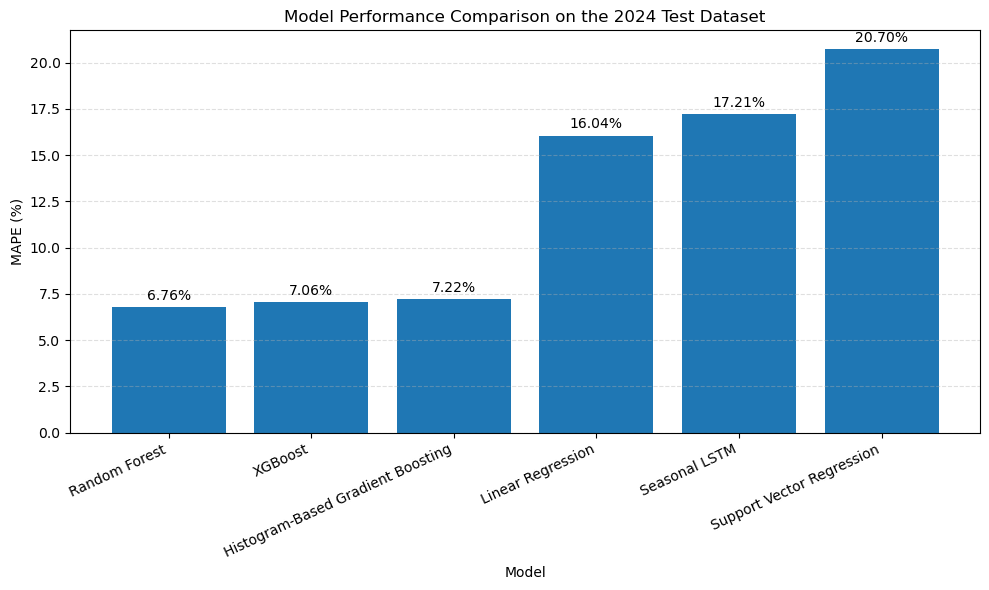

In [121]:
model_plot_data = (
    final_model_comparison
    .sort_values("MAPE (%)")
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    model_plot_data["Model"],
    model_plot_data["MAPE (%)"]
)

plt.ylabel("MAPE (%)")
plt.xlabel("Model")
plt.title("Model Performance Comparison on the 2024 Test Dataset")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar, value in zip(bars, model_plot_data["MAPE (%)"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "Figure_2_7_1_1_Model_MAPE_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 11. Prediction Uncertainty

Prediction ranges were estimated using the distribution of forecasts generated by the 200 individual trees in the final Random Forest.

In [122]:
rf_final = rf_seasonal

rf_actual = seasonal_actual
rf_predicted = seasonal_pred

print("Final Random Forest MAPE:", round(seasonal_mape, 3))
print("Number of trees:", len(rf_final.estimators_))
print("Test observations:", len(rf_predicted))

Final Random Forest MAPE: 6.763
Number of trees: 200
Test observations: 432


In [123]:
X_test_tree = X_test_seasonal.to_numpy()

print("Tree test shape:", X_test_tree.shape)

Tree test shape: (432, 35)


In [124]:
tree_predictions_log = np.column_stack([
    tree.predict(X_test_tree)
    for tree in rf_final.estimators_
])

print(
    "Tree prediction matrix:",
    tree_predictions_log.shape
)

Tree prediction matrix: (432, 200)


In [125]:
tree_predictions = np.expm1(
    tree_predictions_log
)

print(
    "Tree predictions shape:",
    tree_predictions.shape
)

Tree predictions shape: (432, 200)


In [126]:
print(
    "Minimum tree prediction:",
    tree_predictions.min()
)

print(
    "Missing values:",
    np.isnan(tree_predictions).sum()
)

Minimum tree prediction: 2837983453.658998
Missing values: 0


In [127]:
rf_lower = np.percentile(
    tree_predictions,
    2.5,
    axis=1
)

rf_upper = np.percentile(
    tree_predictions,
    97.5,
    axis=1
)

In [128]:
print("Lower bounds:", rf_lower.shape)
print("Upper bounds:", rf_upper.shape)

print(
    "Invalid ranges:",
    np.sum(rf_lower > rf_upper)
)

Lower bounds: (432,)
Upper bounds: (432,)
Invalid ranges: 0


In [129]:
within_range = (
    (rf_actual >= rf_lower) &
    (rf_actual <= rf_upper)
)

coverage = within_range.mean() * 100

print("Empirical coverage:", coverage)

Empirical coverage: 93.51851851851852


In [130]:
interval_width = rf_upper - rf_lower

mean_width = interval_width.mean() / 1e9
median_width = np.median(interval_width) / 1e9

print("Mean width (USD bn):", mean_width)
print("Median width (USD bn):", median_width)

Mean width (USD bn): 19.62639245146007
Median width (USD bn): 15.886532544213901


In [131]:
uncertainty_summary = pd.DataFrame({
    "Interval method": [
        "Random Forest tree-percentile range"
    ],
    "Lower percentile": [2.5],
    "Upper percentile": [97.5],
    "Empirical coverage (%)": [
        coverage
    ],
    "Mean interval width (USD bn)": [
        mean_width
    ],
    "Median interval width (USD bn)": [
        median_width
    ]
})

display(uncertainty_summary.round(3))

,Interval method,Lower percentile,Upper percentile,Empirical coverage (%),Mean interval width (USD bn),Median interval width (USD bn)
0,Random Forest tree-percentile range,2.5,97.5,93.519,19.626,15.887


In [132]:
uncertainty_results = seasonal_test_meta.copy()

uncertainty_results["Actual"] = rf_actual
uncertainty_results["Predicted"] = rf_predicted
uncertainty_results["Lower"] = rf_lower
uncertainty_results["Upper"] = rf_upper
uncertainty_results["Within_Range"] = within_range

print("Rows:", len(uncertainty_results))

Rows: 432


In [133]:
country_coverage = (
    uncertainty_results
    .groupby("country_name")["Within_Range"]
    .mean()
    .mul(100)
    .sort_values()
    .reset_index(name="Coverage (%)")
)

display(country_coverage.round(2))

,country_name,Coverage (%)
0,United_States,83.33
1,China,83.33
2,India,83.33
3,Republic_of_Korea,87.50
4,Brazil,87.50
5,United_Kingdom,87.50
6,Germany,87.50
7,Mexico,91.67
8,Argentina,91.67
9,Italy,100.00


In [134]:
china_export_uncertainty = uncertainty_results[
    (uncertainty_results["country_name"] == "China") &
    (uncertainty_results["flowCode"] == "X")
].sort_values("date").reset_index(drop=True)

print(
    "China export observations:",
    len(china_export_uncertainty)
)

China export observations: 12


In [135]:
china_export_plot = china_export_uncertainty.copy()

china_export_plot["Actual_bn"] = (
    china_export_plot["Actual"] / 1e9
)

china_export_plot["Predicted_bn"] = (
    china_export_plot["Predicted"] / 1e9
)

china_export_plot["Lower_bn"] = (
    china_export_plot["Lower"] / 1e9
)

china_export_plot["Upper_bn"] = (
    china_export_plot["Upper"] / 1e9
)

In [136]:
china_export_plot[
    [
        "date",
        "Actual_bn",
        "Predicted_bn",
        "Lower_bn",
        "Upper_bn"
    ]
].round(2)

,date,Actual_bn,Predicted_bn,Lower_bn,Upper_bn
0,2024-01-01,306.28,284.14,237.81,303.53
1,2024-02-01,221.68,213.17,193.59,262.78
2,2024-03-01,279.21,287.44,272.87,303.53
3,2024-04-01,291.91,286.85,268.97,303.53
4,2024-05-01,301.75,293.37,268.13,334.92
5,2024-06-01,307.32,294.65,268.13,334.92
6,2024-07-01,300.23,288.70,268.94,310.64
7,2024-08-01,308.26,287.21,268.94,303.53
8,2024-09-01,303.40,288.17,274.22,303.53
9,2024-10-01,308.88,287.28,268.94,303.53


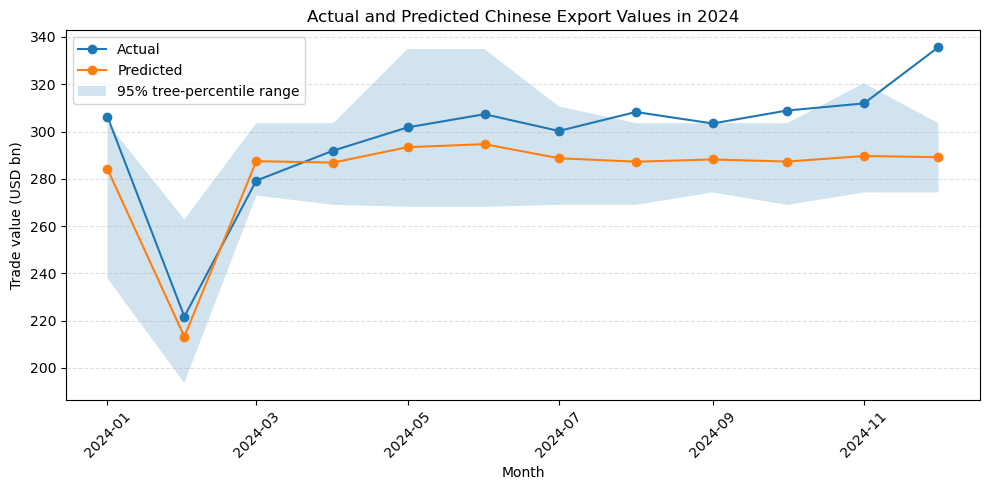

In [137]:
plt.figure(figsize=(10, 5))

plt.plot(
    china_export_plot["date"],
    china_export_plot["Actual_bn"],
    marker="o",
    label="Actual"
)

plt.plot(
    china_export_plot["date"],
    china_export_plot["Predicted_bn"],
    marker="o",
    label="Predicted"
)

plt.ylabel("Trade value (USD bn)")
plt.xlabel("Month")

plt.title(
    "Actual and Predicted Chinese Export Values in 2024"
)

plt.fill_between(
    china_export_plot["date"],
    china_export_plot["Lower_bn"],
    china_export_plot["Upper_bn"],
    alpha=0.2,
    label="95% tree-percentile range"
)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.xticks(rotation=45)
plt.tight_layout()


plt.savefig(
    "Figure_2_7_5_1_China_Export_Uncertainty.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [138]:
uncertainty_summary.to_csv(
    "final_uncertainty_summary.csv",
    index=False
)

print("Uncertainty summary saved")

Uncertainty summary saved


## 12. SHAP Explainability

SHAP was used to examine the contribution of each predictor to the forecasts produced by the final Random Forest.

In [139]:
import shap
import matplotlib.pyplot as plt

X_shap = X_test_seasonal.copy()

explainer = shap.TreeExplainer(
    rf_final
)

shap_values_final = explainer(
    X_shap
)

print("SHAP values calculated")
print("Shape:", shap_values_final.values.shape)

SHAP values calculated
Shape: (432, 35)


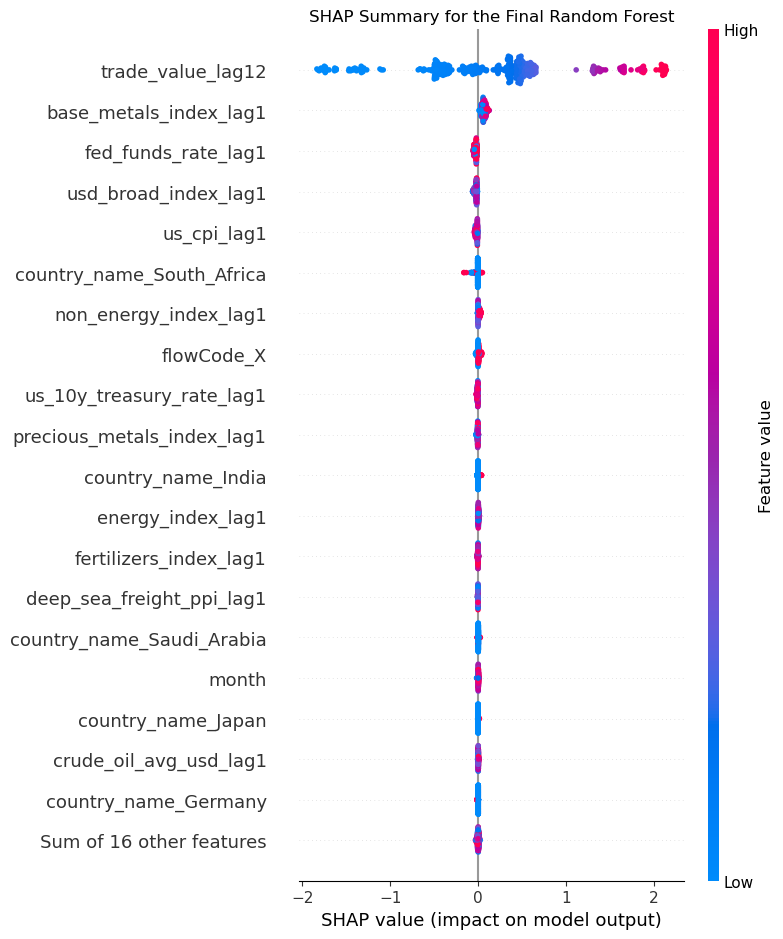

In [140]:
plt.figure()

shap.plots.beeswarm(
    shap_values_final,
    max_display=20,
    show=False
)

plt.title(
    "SHAP Summary for the Final Random Forest"
)

plt.tight_layout()

plt.savefig(
    "Figure_2_7_4_1_SHAP_Summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [141]:
mean_abs_shap = np.abs(
    shap_values_final.values
).mean(axis=0)

In [142]:
shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_Absolute_SHAP": mean_abs_shap
})

In [143]:
shap_importance = (
    shap_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

display(shap_importance.head(15))

,Feature,Mean_Absolute_SHAP
0,trade_value_lag12,0.742540
1,base_metals_index_lag1,0.063967
2,fed_funds_rate_lag1,0.029434
3,usd_broad_index_lag1,0.024665
4,us_cpi_lag1,0.018174
5,country_name_South_Africa,0.009549
6,non_energy_index_lag1,0.007720
7,flowCode_X,0.006836
8,us_10y_treasury_rate_lag1,0.006469
9,precious_metals_index_lag1,0.005242
